In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset,DataLoader 
from transformers import BertTokenizer

d:\RAG_with_langchain\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("url_dataset/malicious_phish.csv")
df.head(5)

,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement


Axes(0.125,0.11;0.775x0.77)


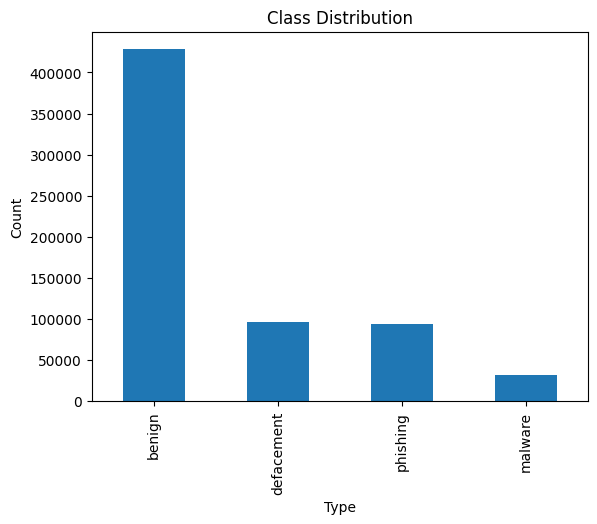

In [3]:
print(df["type"].value_counts().plot(kind='bar'))
plt.xlabel('Type')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()

In [4]:
df['label'] = df['type'].apply(lambda x: 'benign' if x == 'benign' else 'malicious')
df['label'] = df['label'].astype('category').cat.codes #malicious = 1, benign = 0
print(df.head())
print(df['label'].value_counts())

                                                 url        type  label
0                                   br-icloud.com.br    phishing      1
1                mp3raid.com/music/krizz_kaliko.html      benign      0
2                    bopsecrets.org/rexroth/cr/1.htm      benign      0
3  http://www.garage-pirenne.be/index.php?option=...  defacement      1
4  http://adventure-nicaragua.net/index.php?optio...  defacement      1
label
0    428103
1    223088
Name: count, dtype: int64


In [5]:
X = df['url']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=1) 

In [6]:
print("Train label distribution:")
print(y_train.value_counts(normalize=True))

print("\nVal label distribution:")
print(y_val.value_counts(normalize=True))

print("\nTest label distribution:")
print(y_test.value_counts(normalize=True))


Train label distribution:
label
0    0.657673
1    0.342327
Name: proportion, dtype: float64

Val label distribution:
label
0    0.65699
1    0.34301
Name: proportion, dtype: float64

Test label distribution:
label
0    0.657069
1    0.342931
Name: proportion, dtype: float64


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
class Url_Dataset(Dataset):
    def __init__(self, urls, labels, tokenizer, max_length=64):
        self.urls = urls
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.urls)

    def __getitem__(self, idx):
        url = str(self.urls.iloc[idx])  # ensure string
        label = self.labels.iloc[idx]

        # Tokenize URL with padding and truncation
        encoding = self.tokenizer(
            url,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        # encoding['input_ids'], encoding['attention_mask'] are shape [1, max_length]
        # Squeeze to remove batch dimension
        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': torch.tensor(label, dtype=torch.long)
        }


In [9]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=64):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0) 
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


In [ ]:
class URLTransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, num_heads=2, num_layers=2, max_seq_len=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.positional_encoding = PositionalEncoding(embed_dim)
        self.transformer_encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=512,
            dropout=0.2,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(
            self.transformer_encoder_layer,
            num_layers=num_layers
        )
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1),       
            nn.Sigmoid()             # Output between 0 and 1
        )
            
    def forward(self, input_ids, mask=None):
        x = self.embedding(input_ids)
        x = x + self.positional_encoding(x)
        
        if mask is not None:
            # Transformer expects mask of shape (batch_size, seq_len)
            x = self.transformer_encoder(x, src_key_padding_mask=(mask == 0))
        else:
            x = self.transformer_encoder(x)
        pooled = x.mean(dim=1)  # or x[:, 0] if you use a [CLS] token
        out = self.classifier(pooled)
        out = self.classifier(x)
        return out



In [19]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

train_dataset = Url_Dataset(X_train, y_train, tokenizer, max_length=64)
val_dataset = Url_Dataset(X_val, y_val, tokenizer, max_length=64)
test_dataset = Url_Dataset(X_test, y_test, tokenizer, max_length=64)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [20]:
batch = next(iter(train_loader))
print(batch['input_ids'].shape)        # (batch_size, seq_len)
print(batch['attention_mask'].shape)   # (batch_size, seq_len)
print(batch['labels'].shape)            # (batch_size,)


torch.Size([32, 64])
torch.Size([32, 64])
torch.Size([32])


In [21]:
model = URLTransformerClassifier(
    vocab_size=tokenizer.vocab_size,
    embed_dim=256,
    num_heads=2,
    num_layers=2,
    max_seq_len=64
)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [22]:
model

URLTransformerClassifier(
  (embedding): Embedding(30522, 256)
  (positional_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder_layer): TransformerEncoderLayer(
    (self_attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
    )
    (linear1): Linear(in_features=256, out_features=256, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
    (linear2): Linear(in_features=256, out_features=256, bias=True)
    (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (dropout1): Dropout(p=0.2, inplace=False)
    (dropout2): Dropout(p=0.2, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features

In [23]:
sample = train_dataset[0]

print("Input IDs:", sample['input_ids'])               # Tensor of token IDs
print("Tokens:   ", tokenizer.convert_ids_to_tokens(sample['input_ids']))
print("Attention Mask:", sample['attention_mask'])
print("Label:", sample['labels'])


Input IDs: tensor([  101,  2188, 13704,  1012, 23961,  2140, 11108,  1012,  4012,  1013,
        21326, 10448,  2140,  1013,   102,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0])
Tokens:    ['[CLS]', 'home', '##page', '.', 'nt', '##l', '##world', '.', 'com', '/', 'roc', '##oi', '##l', '/', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[P

In [ ]:
def train_model(model, train_loader, val_loader, optimizer, criterion, device, num_epochs=25, patience=3):
    model.to(device)
    
    best_val_acc = 0.0
    best_model_state = None
    epochs_no_improve = 0
    
    for epoch in range(num_epochs):
        # --- Training ---
        model.train()
        total_loss = 0
        correct = 0
        total = 0
        
        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch.get('attention_mask')
            if attention_mask is not None:
                attention_mask = attention_mask.to(device)
            labels = batch['labels'].float().to(device)
            
            optimizer.zero_grad()
            if attention_mask is not None:
                outputs = model(input_ids, attention_mask).squeeze(1)
            else:
                outputs = model(input_ids).squeeze(1)
            
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            preds = (outputs > 0.5).long()
            correct += (preds == labels.long()).sum().item()
            total += labels.size(0)
        
        train_loss = total_loss / len(train_loader)
        train_acc = correct / total
        
        # --- Validation ---
        val_acc = evaluate_model(model, val_loader, device)
        
        print(f"Epoch {epoch+1}/{num_epochs} — Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")
        
        # --- Early Stopping Check ---
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs.")
            break
    
    # Load best model weights before returning
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return model


@torch.no_grad()
def evaluate_model(model, data_loader, device):
    model.eval()
    correct = 0
    total = 0
    
    for batch in data_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device) 
        labels = batch['labels'].to(device)
        
        outputs = model(input_ids,mask = attention_mask).squeeze(1)
        preds = (outputs > 0.5).long()
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    return correct / total


In [25]:
trained_model = train_model(model, train_loader, val_loader, optimizer, criterion, device, num_epochs=1)

# Finally evaluate on test set:
test_acc = evaluate_model(trained_model, test_loader, device)
print(f"Test Accuracy: {test_acc:.4f}")


KeyboardInterrupt: 

In [ ]:
torch.save(model.state_dict(), "save_urlScanner/transformer_ver_1.1.pth")